# FinOptix Summer Project '25 — Final Implementation

**Stock selection using ML predictions + fundamentals, portfolio optimization with Black-Litterman**

Vandit Gupta | Finance & Analytics Club, IIT Kanpur

This notebook consolidates my final project implementation:
1. Download NIFTY 50 data
2. Feature engineering (technical indicators)
3. Per-stock XGBoost return prediction + evaluation
4. Stock scoring (ML + fundamentals) and top-20 selection
5. Black-Litterman portfolio optimization (PyPortfolioOpt)
6. Performance simulation vs equal-weight and NIFTY 50

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Data Collection

Universe: NIFTY 50 constituents (49 tickers with full history), daily data 2019-2025 from Yahoo Finance.
I cache everything to csv because re-downloading 50 stocks every run is slow.

In [2]:
TICKERS = ['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS',
           'BAJAJ-AUTO.NS', 'BAJAJFINSV.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'BPCL.NS',
           'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS',
           'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS',
           'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS',
           'INFY.NS', 'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS',
           'M&M.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS',
           'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'SHREECEM.NS',
           'SUNPHARMA.NS', 'TATACONSUM.NS', 'TATASTEEL.NS', 'TCS.NS', 'TECHM.NS',
           'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS']

START, END = "2019-01-01", "2025-06-30"

if os.path.exists("prices.csv"):
    prices = pd.read_csv("prices.csv", index_col=0, parse_dates=True)
    volumes = pd.read_csv("volumes.csv", index_col=0, parse_dates=True)
    nifty = pd.read_csv("benchmark.csv", index_col=0, parse_dates=True)["NIFTY50"]
else:
    raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
    prices = raw["Close"].ffill(limit=5)
    volumes = raw["Volume"]
    nifty = yf.download("^NSEI", start=START, end=END, auto_adjust=True)["Close"].squeeze()
    prices.to_csv("prices.csv")
    volumes.to_csv("volumes.csv")
    nifty.to_frame("NIFTY50").to_csv("benchmark.csv")

print(prices.shape)
prices.iloc[-3:, :5]

(1603, 49)


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS
Date,,,,,
2025-06-25,2526.070557,1387.253418,7023.673340,2256.767578,1212.264038
2025-06-26,2585.044189,1423.301636,7083.018555,2266.567383,1232.446777
2025-06-27,2645.117432,1434.155762,7289.479492,2334.768066,1224.053833


## 2. Feature Engineering

Technical indicators per stock (horizon = 21 days for the momentum smoothing):
returns, 20-day volatility, 10/50-day moving averages, momentum (10 & 50), Bollinger bands,
return-volume correlation and lagged returns. Target = next day return.

In [3]:
def calculate_features(close, volume, horizon=21):
    df = pd.DataFrame(index=close.index)
    df["returns"] = close.pct_change()
    df["volatility_20"] = df["returns"].rolling(20).std()
    df["ma_10"] = close.rolling(10).mean() / close - 1
    df["ma_50"] = close.rolling(50).mean() / close - 1
    df["momentum_10"] = close.pct_change(10).rolling(horizon).mean()
    df["momentum_50"] = close.pct_change(50).rolling(horizon).mean()
    ma20 = close.rolling(20).mean()
    sd20 = close.rolling(20).std()
    df["bb_upper"] = (ma20 + 2 * sd20) / close - 1
    df["bb_lower"] = (ma20 - 2 * sd20) / close - 1
    v = volume.replace(0, np.nan).ffill()
    df["vol_corr"] = df["returns"].rolling(20).corr(v.pct_change())
    df["ret_lag1"] = df["returns"].shift(1)
    df["ret_lag2"] = df["returns"].shift(2)
    df["target"] = df["returns"].shift(-1)
    return df.dropna()

# quick sanity check on one stock
calculate_features(prices["RELIANCE.NS"], volumes["RELIANCE.NS"]).tail(3)

,returns,volatility_20,ma_10,ma_50,momentum_10,momentum_50,bb_upper,bb_lower,vol_corr,ret_lag1,ret_lag2,target
Date,,,,,,,,,,,,
2025-06-24,-0.004119,0.008364,-0.005749,-0.035508,0.003709,0.151927,0.010750,-0.033075,0.422300,-0.006411,0.022954,0.011373
2025-06-25,0.011373,0.008473,-0.015675,-0.042969,0.004099,0.154565,0.002230,-0.043087,0.303701,-0.004119,-0.006411,0.019083
2025-06-26,0.019083,0.009301,-0.030516,-0.057476,0.006257,0.158043,-0.008855,-0.063505,0.378898,0.011373,-0.004119,0.013442


## 3. Return Prediction — XGBoost (one model per stock)

Train period: 2022-03-01 to 2024-05-31. Out-of-sample prediction: 2024-06-01 onwards.

| parameter | value |
|---|---|
| objective | reg:squarederror |
| n_estimators | 2000 |
| max_depth | 12 |
| learning_rate | 0.01 |
| subsample / colsample_bytree | 0.8 |

In [4]:
TRAIN_START, TRAIN_END = "2022-03-01", "2024-05-31"
TEST_START = "2024-06-01"

# training all 49 models takes ~10 min, so predictions are cached to csv
# delete predictions.csv to retrain from scratch
if os.path.exists("predictions.csv"):
    predictions = pd.read_csv("predictions.csv", index_col=0, parse_dates=True)
    actuals = pd.read_csv("actuals.csv", index_col=0, parse_dates=True)
else:
    predictions, actuals = {}, {}
    for t in TICKERS:
        feats = calculate_features(prices[t], volumes[t])
        X, y = feats.drop(columns="target"), feats["target"]
        X_tr, y_tr = X.loc[TRAIN_START:TRAIN_END], y.loc[TRAIN_START:TRAIN_END]
        X_te, y_te = X.loc[TEST_START:], y.loc[TEST_START:]
        model = XGBRegressor(objective="reg:squarederror", n_estimators=2000,
                             max_depth=12, learning_rate=0.01, subsample=0.8,
                             colsample_bytree=0.8, random_state=42)
        model.fit(X_tr, y_tr)
        predictions[t] = pd.Series(model.predict(X_te), index=X_te.index)
        actuals[t] = y_te
        print(t, "done")
    predictions = pd.DataFrame(predictions)
    actuals = pd.DataFrame(actuals)
    predictions.to_csv("predictions.csv")
    actuals.to_csv("actuals.csv")

print("prediction period:", predictions.index[0].date(), "to", predictions.index[-1].date(),
      "|", predictions.shape[0], "days")

prediction period: 2024-06-03 to 2025-06-26 | 266 days


### Model evaluation — correlation and RMSE per stock

In [5]:
evals = pd.DataFrame({
    "correlation": {t: predictions[t].corr(actuals[t]) for t in predictions.columns},
    "rmse": {t: np.sqrt(((predictions[t] - actuals[t]) ** 2).mean()) for t in predictions.columns},
}).sort_values("correlation", ascending=False)

print("mean correlation: %.4f | stocks with corr > 0: %d/49"
      % (evals["correlation"].mean(), (evals["correlation"] > 0).sum()))
evals.round(4).head(10)

mean correlation: 0.0135 | stocks with corr > 0: 32/49


,correlation,rmse
ICICIBANK.NS,0.1728,0.0126
POWERGRID.NS,0.1492,0.0180
AXISBANK.NS,0.1243,0.0154
WIPRO.NS,0.0942,0.0194
SUNPHARMA.NS,0.0798,0.0134
JSWSTEEL.NS,0.0751,0.0186
SHREECEM.NS,0.0741,0.0151
BAJAJFINSV.NS,0.0725,0.0174
HDFCBANK.NS,0.0633,0.0146
INDUSINDBK.NS,0.0583,0.0287


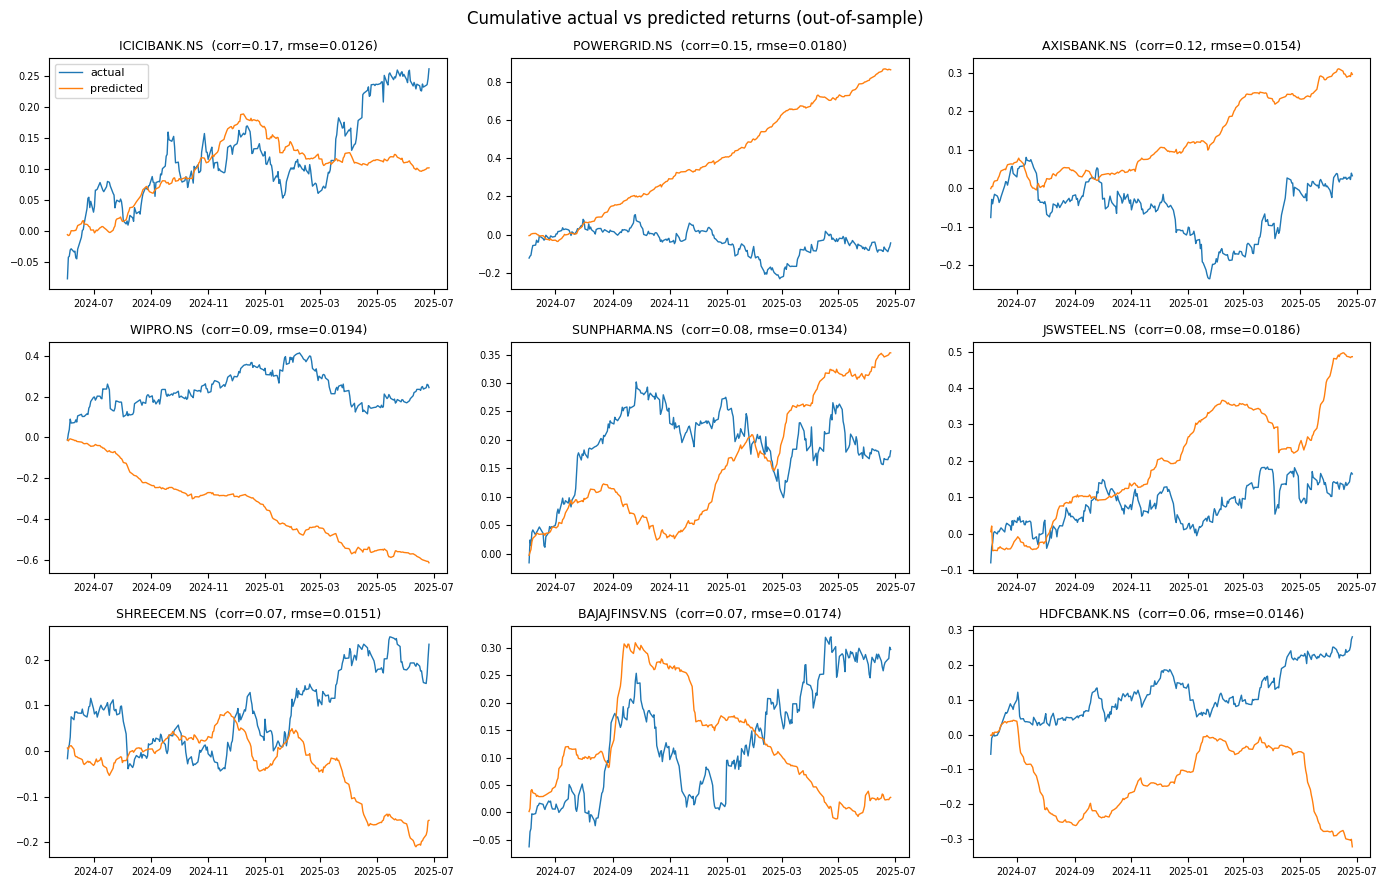

In [6]:
# actual vs predicted returns for the 9 best-correlated stocks
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, t in zip(axes.flat, evals.index[:9]):
    ax.plot(actuals[t].cumsum(), label="actual", lw=1)
    ax.plot(predictions[t].cumsum(), label="predicted", lw=1)
    ax.set_title("%s  (corr=%.2f, rmse=%.4f)" % (t, evals.loc[t, "correlation"], evals.loc[t, "rmse"]), fontsize=9)
    ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Cumulative actual vs predicted returns (out-of-sample)")
fig.tight_layout()
plt.show()

## 4. Stock Scoring & Selection

Combine ML predictions with fundamentals into one score:
1. **Expected return score** — mean of predicted returns (higher better)
2. **P/E score** — inverse normalized (lower P/E preferred)
3. **D/E score** — inverse normalized (lower debt preferred)
4. **Market cap score** — normalized (higher preferred)

Weights: 0.4 / 0.2 / 0.2 / 0.2. Top 20 stocks selected by final score.

In [7]:
funda = pd.read_csv("fundamentals_full.csv", index_col=0)

scores = pd.DataFrame(index=predictions.columns)
scores["exp_return"] = predictions.mean()
scores["pe"] = funda["trailingPE"]
scores["de"] = funda["debtToEquity"]
scores["mcap"] = funda["marketCap"]
# a couple of tickers have missing fundamentals -> fill with median
scores = scores.fillna(scores.median())

def normalize(s, inverse=False):
    s = (s - s.min()) / (s.max() - s.min())
    return 1 - s if inverse else s

w_r, w_p, w_d, w_m = 0.4, 0.2, 0.2, 0.2
scores["final_score"] = (w_r * normalize(scores["exp_return"])
                         + w_p * normalize(scores["pe"], inverse=True)
                         + w_d * normalize(scores["de"], inverse=True)
                         + w_m * normalize(scores["mcap"]))

top20 = scores["final_score"].nlargest(20)
top20.round(3)

HEROMOTOCO.NS    0.774
RELIANCE.NS      0.771
COALINDIA.NS     0.752
SBIN.NS          0.723
NTPC.NS          0.722
ONGC.NS          0.696
BPCL.NS          0.660
ICICIBANK.NS     0.648
TCS.NS           0.642
ITC.NS           0.639
BHARTIARTL.NS    0.633
BAJAJ-AUTO.NS    0.631
M&M.NS           0.631
MARUTI.NS        0.627
HDFCBANK.NS      0.622
CIPLA.NS         0.619
AXISBANK.NS      0.611
HINDALCO.NS      0.593
POWERGRID.NS     0.593
HCLTECH.NS       0.590
Name: final_score, dtype: float64

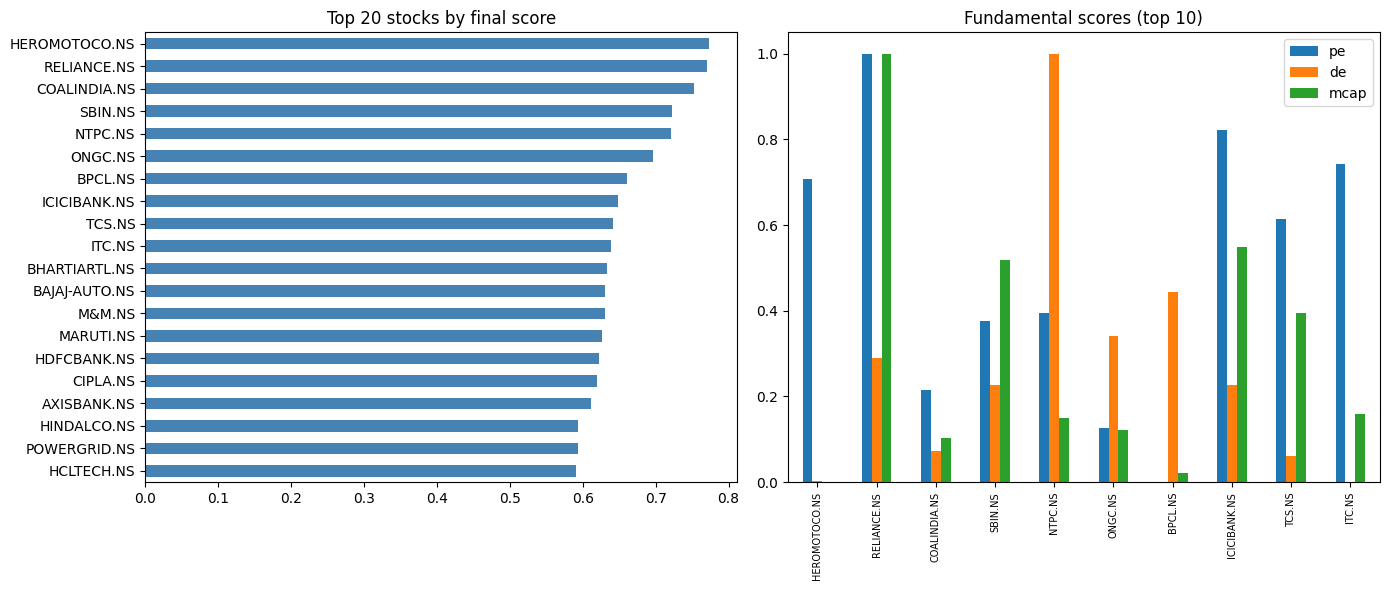

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
top20.sort_values().plot(kind="barh", ax=ax1, color="steelblue")
ax1.set_title("Top 20 stocks by final score")

comp = scores.loc[top20.index[:10], ["pe", "de", "mcap"]].apply(lambda c: normalize(c))
comp.plot(kind="bar", ax=ax2)
ax2.set_title("Fundamental scores (top 10)")
ax2.tick_params(axis="x", labelsize=7)
fig.tight_layout()
plt.show()

## 5. Black-Litterman Portfolio Optimization

Using PyPortfolioOpt on the top-20 stocks:
- Implied equilibrium returns $\\Pi = \\delta \\Sigma w_{mkt}$ with $\\delta = 2.5$, equal market weights
- My views on a few stocks are blended in (these are subjective - one of the limitations)
- Max Sharpe optimization on the posterior returns/covariance

In [9]:
from pypfopt import risk_models, EfficientFrontier
from pypfopt.black_litterman import BlackLittermanModel

port_prices = prices[top20.index].loc["2020-01-01":"2024-12-31"]
S = risk_models.sample_cov(port_prices)

delta = 2.5
w_mkt = pd.Series(1 / len(top20), index=top20.index)
pi = delta * S.dot(w_mkt)

# my views (annual returns) - only applied if the stock made it into the top 20
my_views = {"HDFCBANK.NS": 0.15, "ICICIBANK.NS": 0.14, "TCS.NS": 0.08,
            "RELIANCE.NS": 0.10, "ITC.NS": 0.07, "WIPRO.NS": -0.02}
viewdict = {k: v for k, v in my_views.items() if k in top20.index}
print("active views:", viewdict)

bl = BlackLittermanModel(S, pi=pi, absolute_views=viewdict)
ret_bl = bl.bl_returns()
S_bl = bl.bl_cov()

ef = EfficientFrontier(ret_bl, S_bl)
ef.max_sharpe(risk_free_rate=0.02)
bl_weights = pd.Series(ef.clean_weights())
bl_weights[bl_weights > 0.01].sort_values(ascending=False).round(3)

active views: {'HDFCBANK.NS': 0.15, 'ICICIBANK.NS': 0.14, 'TCS.NS': 0.08, 'RELIANCE.NS': 0.1, 'ITC.NS': 0.07}


HDFCBANK.NS      0.211
HINDALCO.NS      0.092
AXISBANK.NS      0.077
ICICIBANK.NS     0.077
M&M.NS           0.072
ONGC.NS          0.060
SBIN.NS          0.059
BPCL.NS          0.059
HEROMOTOCO.NS    0.048
NTPC.NS          0.040
MARUTI.NS        0.039
HCLTECH.NS       0.036
COALINDIA.NS     0.029
BHARTIARTL.NS    0.024
TCS.NS           0.024
RELIANCE.NS      0.022
BAJAJ-AUTO.NS    0.018
POWERGRID.NS     0.014
dtype: float64

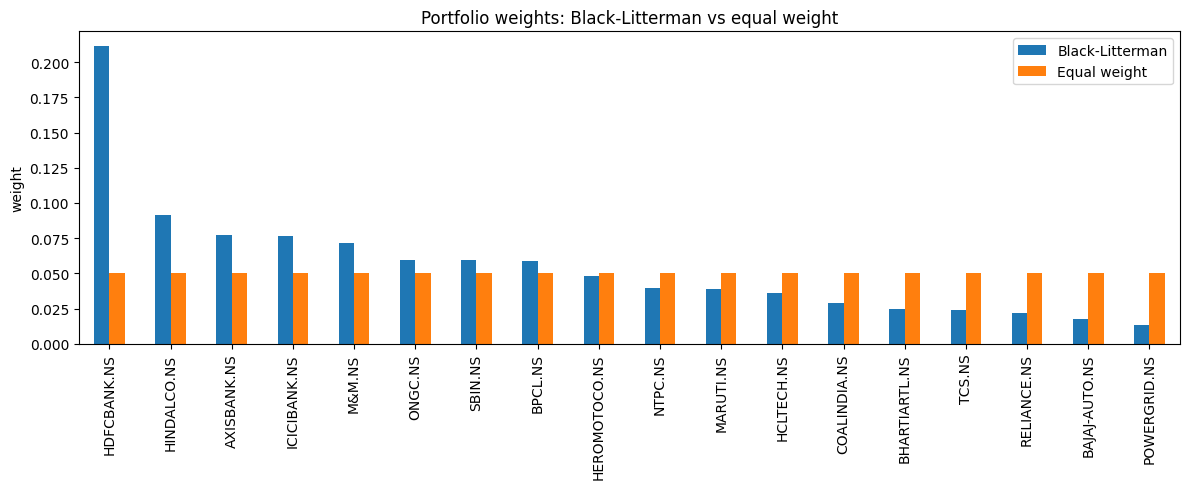

In [10]:
# compare BL weights with equal weight benchmark
eq_weights = pd.Series(1 / len(top20), index=top20.index)

comp = pd.DataFrame({"Black-Litterman": bl_weights, "Equal weight": eq_weights})
comp[comp["Black-Litterman"] > 0.005].sort_values("Black-Litterman", ascending=False).plot(
    kind="bar", figsize=(12, 5))
plt.title("Portfolio weights: Black-Litterman vs equal weight")
plt.ylabel("weight")
plt.tight_layout()
plt.show()

## 6. Performance Simulation

Simulate both portfolios on the out-of-sample period (2024-06 onwards, same window as the
ML predictions) and compare against the NIFTY 50 index.

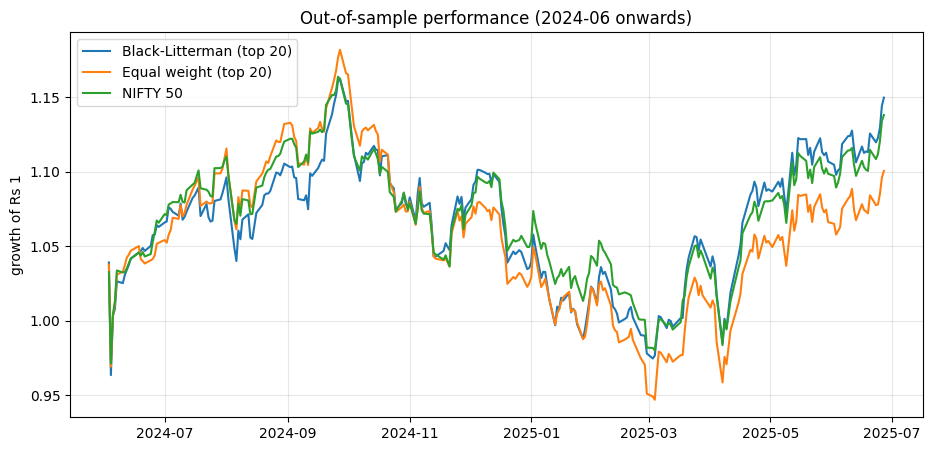

Black-Litterman  cumulative:  14.95% | annualized:  14.06% | vol: 16.98% | sharpe: 0.47
Equal weight     cumulative:  10.04% | annualized:   9.45% | vol: 16.24% | sharpe: 0.21
NIFTY 50         cumulative:  13.79% | annualized:  12.97% | vol: 14.97% | sharpe: 0.47


In [11]:
def simulate_portfolio(weights, period_returns):
    port_ret = (period_returns[weights.index] * weights).sum(axis=1)
    return (1 + port_ret).cumprod()

test_returns = prices.pct_change().loc[TEST_START:]
nifty_curve = (1 + nifty.pct_change().loc[TEST_START:]).cumprod()

bl_curve = simulate_portfolio(bl_weights[bl_weights > 0], test_returns)
eq_curve = simulate_portfolio(eq_weights, test_returns)

plt.figure(figsize=(11, 5))
plt.plot(bl_curve, label="Black-Litterman (top 20)")
plt.plot(eq_curve, label="Equal weight (top 20)")
plt.plot(nifty_curve, label="NIFTY 50")
plt.title("Out-of-sample performance (2024-06 onwards)")
plt.ylabel("growth of Rs 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, curve in [("Black-Litterman", bl_curve), ("Equal weight", eq_curve), ("NIFTY 50", nifty_curve)]:
    r = curve.pct_change().dropna()
    ann = curve.iloc[-1] ** (252 / len(curve)) - 1
    vol = r.std() * np.sqrt(252)
    print("%-16s cumulative: %6.2f%% | annualized: %6.2f%% | vol: %5.2f%% | sharpe: %.2f"
          % (name, (curve.iloc[-1] - 1) * 100, ann * 100, vol * 100, (ann - 0.06) / vol))

## Observations

1. XGBoost picks up some signal from technical indicators but correlation varies a lot
   between stocks - for most it is between -0.1 and +0.15, so the predictions are only
   useful in aggregate (for ranking), not for timing individual stocks.
2. Combining the ML score with fundamental filters (P/E, D/E, market cap) makes the
   selection more robust than using predicted returns alone.
3. Black-Litterman gives a disciplined way to mix equilibrium returns with my own views -
   the optimized portfolio is more concentrated than equal weight.
4. **Limitations:** views are subjective placeholders, no transaction costs in the
   simulation, fundamentals are current values (not point-in-time), and the model
   predicts next-day returns which is very noisy.